In [354]:
import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import numpy as onp
import numpy.typing as npt
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from tqdm import tqdm
from typing import Callable, NamedTuple

from msmjax.bspline_basis import create_bspline_basis_element

In [232]:
ORDER = 5

# Grid construction

In [369]:
# class GridAxis1D():
#     def __init__(self, length: float, h: float, p: int):
#         if p % 2 != 0:
#             raise ValueError("p must be even")
#         self.length = length
#         self.h = h
#         self.p = p
# 
#         # TODO: periodic (this only holds for nonperiodic)
#         self.n_domain = int(onp.ceil(self.length / h))
#         self.n_total = self.n_domain + p
# 
#     def process_raw_indices(self, raw_indices: npt.ArrayLike):
#         # TODO: periodic (this only holds for nonperiodic)
#         return raw_indices + self.p // 2
# 
#     def find_grid_indices_in_splinerange(self, x: float):
#         ref_index = jnp.ceil(x / h).astype(int)
#         raw_indices = ref_index + jnp.arange(-p // 2, p // 2)
#         # TODO: should this return raw or processed indices?
#         return self.process_raw_indices(raw_indices)


class GridAxis1D(NamedTuple):
    periodic: bool
    length: float
    h: float
    n_domain: int
    n_total: int
    process_raw_indices: Callable
    find_grid_indices_in_splinerange: Callable


def set_up_grid_axis(length: float, h: float, p: int, periodic: bool = False):
    if p % 2 != 0:
        raise ValueError("p must be even")
    if periodic:
        raise ValueError("Periodic axes not supported yet.")

    n_domain = int(onp.ceil(length / h))
    n_total = n_domain + p

    if periodic:
        raise  # TODO
    else:
        def process_raw_indices(raw_indices: npt.ArrayLike):
            # TODO: periodic (this only holds for nonperiodic)
            return raw_indices + p // 2

    def find_grid_indices_in_splinerange(x: float):
        ref_index = jnp.ceil(x / h).astype(int)
        raw_indices = ref_index + jnp.arange(-p // 2, p // 2)
        # TODO: should this return raw or processed indices?
        return process_raw_indices(raw_indices)

    return GridAxis1D(
        periodic=periodic,
        length=length,
        h=h,
        n_domain=n_domain,
        n_total=n_total,
        process_raw_indices=process_raw_indices,
        find_grid_indices_in_splinerange=find_grid_indices_in_splinerange
    )


In [361]:
gridax = set_up_grid_axis(length=10.0, h=1.0, p=ORDER-1)

In [363]:
gridax.find_grid_indices_in_splinerange(0.1)

Array([1, 2, 3, 4], dtype=int32)

In [365]:
gridax.process_raw_indices(jnp.array([-1, 0, 1, 2]))

Array([1, 2, 3, 4], dtype=int32)

In [366]:
jitted = jax.jit(gridax.process_raw_indices)
jitted(jnp.array([-1, 0, 1, 2]))
jitted(jnp.array([-1, 0, 1, 2]))

Array([1, 2, 3, 4], dtype=int32)

In [368]:
jitted = jax.jit(gridax.find_grid_indices_in_splinerange)
jitted(0.4)
jitted(0.0)

Array([0, 1, 2, 3], dtype=int32)

In [299]:
def construct_grid1d_nonperiodic(boxlength: float, gridspacing: float, p: int):
    if p % 2 != 0:
        raise ValueError("p must be even")
    # TODO: check grid spacing greater than box length?

    n_domain_covering = int(onp.ceil(boxlength / gridspacing))
    n_extended = n_domain_covering + p

    def process_raw_indices(raw_indices: npt.ArrayLike):
        return raw_indices + p // 2

    return n_domain_covering, n_extended, process_raw_indices


In [296]:
length = 10.1
h = 1.0
n_domain, n_extended, process_raw_indices = construct_grid1d_nonperiodic(
    boxlength=length, gridspacing=h, p=ORDER - 1)

print(n_domain)
print(onp.arange(n_domain + 1))
print(onp.arange(n_domain + 1) * h)

11
[ 0  1  2  3  4  5  6  7  8  9 10 11]
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11.]


In [297]:
jitted_process_raw_indices = jax.jit(process_raw_indices)

print(jitted_process_raw_indices(jnp.array([-1, 0, 1, 2])))
print(jitted_process_raw_indices(jnp.array([-2, -1, 0, 1])))

[1 2 3 4]
[0 1 2 3]


In [304]:
for h in [0.5, 1.0, 2.0, 4.0]:
    n_domain, n_extended, process_raw_indices = construct_grid1d_nonperiodic(
        boxlength=length, gridspacing=h, p=ORDER - 1)
    gridpoints = onp.arange(n_domain + 1) * h
    print(gridpoints)
    print(len(gridpoints))

[ 0.   0.5  1.   1.5  2.   2.5  3.   3.5  4.   4.5  5.   5.5  6.   6.5
  7.   7.5  8.   8.5  9.   9.5 10.  10.5]
22
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11.]
12
[ 0.  2.  4.  6.  8. 10. 12.]
7
[ 0.  4.  8. 12.]
4


# Grid charge computation

In [22]:
bspline_basis_element = create_bspline_basis_element(order=ORDER)
jitted_bspline_basis = jax.jit(bspline_basis_element)

In [23]:
bspline_basis_element

functools.partial(<function evaluate_basis_element at 0x7f05fa045790>, Array([-3., -2., -1.,  0.,  1.,  2.,  3.], dtype=float32))

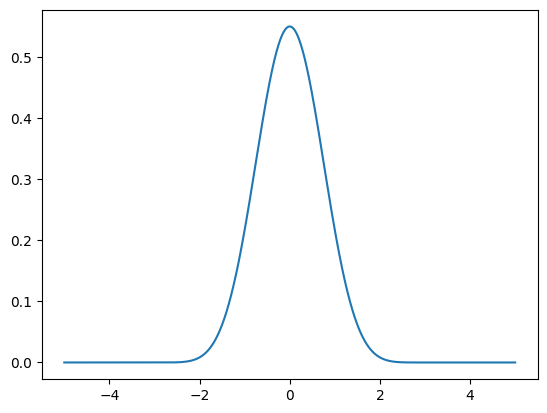

In [24]:
xs = jnp.linspace(-5, 5, 1001)

fig, ax = plt.subplots()
ax.plot(xs, [jitted_bspline_basis(xval) for xval in xs])

In [51]:
h = 0.2
grid = jnp.arange(0, 3 + h / 10, h)

In [52]:
x = 1.25

In [53]:
int(x // h)

6

In [54]:
indices_centered_on = int(x // h) + jnp.arange(-(ORDER + 1) // 2,
                                               (ORDER + 1) // 2 + 1)

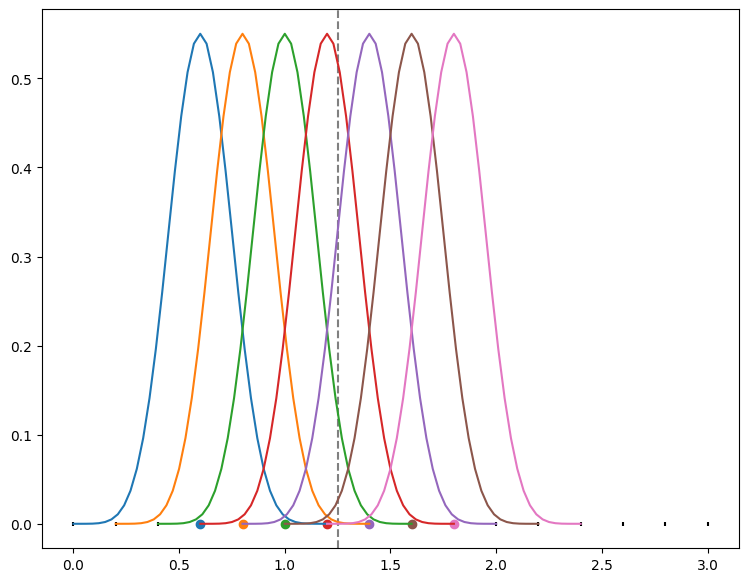

In [55]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(grid, onp.zeros_like(grid), s=5, color="black", marker="|")

ax.axvline(x, linestyle="--", color="gray")

for m in indices_centered_on:  # TODO
    x_m = m * h
    splinerange = jnp.linspace((m - (ORDER + 1) / 2) * h,
                               (m + (ORDER + 1) / 2) * h, 41)
    splinevals = jnp.asarray(
        [jitted_bspline_basis((x - x_m) / h) for x in splinerange])
    ax.scatter(x_m, 0)
    ax.plot(splinerange, splinevals)

In [56]:
int(jnp.floor(x / h))

6

In [57]:
int(jnp.ceil(x / h))

7

In [59]:
# x = 8.4
# x = 8.0
# x = 8.1
# x = 0.0

p = ORDER - 1

indices = jnp.arange(jnp.ceil(x / h).astype(int) - p // 2,
                     jnp.ceil(x / h).astype(int) + p // 2)
indices

Array([5, 6, 7, 8], dtype=int32)

In [96]:
def find_ref_index(x):
    ref_index = jnp.ceil(x / h).astype(int)
    return ref_index


vmapped_find_ref_index = jax.vmap(find_ref_index, in_axes=0)


def find_gridpoints_in_splinerange(x):
    ref_index = jnp.ceil(x / h).astype(int)
    return ref_index + jnp.arange(-p // 2, p // 2)


vmapped_find_gridpoints = jax.vmap(find_gridpoints_in_splinerange)

In [91]:
(jnp.asarray([find_gridpoints_in_splinerange(x) for x in
              [-0.1, 0., 0.01, 1.25, 1.8, 2.1, 3.1123, 3.7568, 4.288]]))

Array([[-2, -1,  0,  1],
       [-2, -1,  0,  1],
       [-1,  0,  1,  2],
       [ 5,  6,  7,  8],
       [ 7,  8,  9, 10],
       [ 9, 10, 11, 12],
       [14, 15, 16, 17],
       [17, 18, 19, 20],
       [20, 21, 22, 23]], dtype=int32)

In [93]:
rng = onp.random.default_rng(1234)

xs = jnp.array(rng.uniform(0., 10., size=5))
vmapped_find_ref_index(xs)

Array([49, 20, 47, 14, 16], dtype=int32)

In [111]:
rng = onp.random.default_rng(1234)

xs = jnp.array(rng.uniform(0., 10.)).reshape((1,))
vmapped_find_gridpoints(xs)

Array([[47, 48, 49, 50]], dtype=int32)

In [115]:
indices = find_gridpoints_in_splinerange(x)

In [125]:
x, indices

(1.25, Array([5, 6, 7, 8], dtype=int32))

In [126]:
x / h, indices

(6.25, Array([5, 6, 7, 8], dtype=int32))

In [155]:
vmapped_bspline_basis = jax.vmap(bspline_basis_element)

vmapped_bspline_basis(x / h - indices)

Array([0.12491049, 0.5196452 , 0.3280762 , 0.02538249], dtype=float32)

In [104]:
bspline_basis_element(x / h)

Array(0., dtype=float32)

In [191]:
rng = onp.random.default_rng(1234)

jitted_find_gridpoints = jax.jit(vmapped_find_gridpoints)

n_particles = 10

for batch_index in tqdm(range(10)):
    xs = jnp.array(rng.uniform(0.5, 2.5, size=n_particles))
    qs = jnp.array(rng.uniform(-1., 1., size=n_particles))
    grid_indices = vmapped_find_gridpoints(xs)

100%|██████████| 10/10 [00:00<00:00, 67.47it/s]


In [181]:
xs.shape, grid_indices.shape

((10,), (10, 4))

In [213]:
vmapped_bspline_basis = jax.vmap(jax.vmap(bspline_basis_element))

dists_on_grid = (xs / h)[:, jnp.newaxis] - grid_indices

spline_values = vmapped_bspline_basis(dists_on_grid)

In [214]:
spline_values.shape

(10, 4)

In [215]:
grid_indices.shape, spline_values.shape

((10, 4), (10, 4))

In [216]:
grid_indices[0], spline_values[0]

(Array([10, 11, 12, 13], dtype=int32),
 Array([0.18470913, 0.5468571 , 0.25071308, 0.01221054], dtype=float32))

In [217]:
grid_charges = jnp.zeros_like(grid)
grid_charges.at[grid_indices[0]].set(spline_values[0])

Array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.18470913, 0.5468571 , 0.25071308, 0.01221054, 0.        ,
       0.        ], dtype=float32)

In [218]:
inds = jnp.array([2, 2, 2])
vals = jnp.array([1, 1, 1])

grid_charges = jnp.zeros_like(grid)
grid_charges.at[inds].add(vals)

Array([0., 0., 3., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],      dtype=float32)

In [219]:
inds = jnp.array([[2, 2, 2], [3, 3, 3]])
vals = jnp.array([[1, 1, 1], [2, 3, 4]])

grid_charges = jnp.zeros_like(grid)
grid_charges.at[inds].add(vals)

Array([0., 0., 3., 9., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],      dtype=float32)

In [220]:
grid_charges = jnp.zeros_like(grid)
grid_charges = grid_charges.at[grid_indices].add(
    qs[:, jnp.newaxis] * spline_values)

grid_charges

Array([ 0.        ,  0.        , -0.0460084 , -0.264046  , -0.16894095,
        0.21878968,  0.12181178, -0.21531758, -0.07549989, -0.02674545,
       -0.29280666, -0.01156272, -0.230769  , -0.31834608, -0.03158399,
        0.        ], dtype=float32)

In [221]:
grid_charges.sum()

Array(-1.3410252, dtype=float32)

In [ ]:
qs.sum()

## More systematically

In [373]:
def make_compute_gridcharge_1d(grid: GridAxis1D):
    vmapped_find_grid_indices = jax.vmap(grid.find_grid_indices_in_splinerange)
    vmapped_bspline_basis = jax.vmap(jax.vmap(bspline_basis_element))
    
    def compute_gridcharge_1d(positions_1d, charges):
        grid_indices = vmapped_find_grid_indices(positions_1d)
        
        distances_on_grid = (positions_1d / h)[:, jnp.newaxis] - grid_indices
        spline_values = vmapped_bspline_basis(distances_on_grid)
        
        gridcharge = jnp.zeros(grid.n_total)
        gridcharge = gridcharge.at[grid_indices].add(charges[:, jnp.newaxis] * spline_values)
        
        return gridcharge
    
    return compute_gridcharge_1d

In [385]:
length = 10.
h = 0.25

grid = set_up_grid_axis(length=length, h=h, p=ORDER-1)

compute_gridcharge = make_compute_gridcharge_1d(grid)
jitted_compute_gridcharge = jax.jit(compute_gridcharge)

In [392]:
n_particles = 1

rng = onp.random.default_rng(1234)
positions = jnp.array(rng.uniform(0.0, length, size=n_particles))
charges = jnp.array(rng.uniform(-1., 1., size=n_particles))

print("- Call to trigger compilation")
gridcharge = jitted_compute_gridcharge(positions, charges)
print("- Second call")
gridcharge = jitted_compute_gridcharge(positions, charges)

- Call to trigger compilation
- Second call


In [395]:
gridcharge

Array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
       -5.8874249e-02, -2.7742968e-03, -2.9008511e-09,  0.0000000e+00],      dtype=float32)